# IMT 573 - Final Examination


Points: 100

Name: Ramon Hernandez

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Ramon Hernandez 

11/28/25

For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [59]:
affairs = sm.datasets.fair.load_pandas().data
print(sm.datasets.fair.NOTE)

::

    Number of observations: 6366
    Number of variables: 9
    Variable name definitions:

        rate_marriage   : How rate marriage, 1 = very poor, 2 = poor, 3 = fair,
                        4 = good, 5 = very good
        age             : Age
        yrs_married     : No. years married. Interval approximations. See
                        original paper for detailed explanation.
        children        : No. children
        religious       : How relgious, 1 = not, 2 = mildly, 3 = fairly,
                        4 = strongly
        educ            : Level of education, 9 = grade school, 12 = high
                        school, 14 = some college, 16 = college graduate,
                        17 = some graduate school, 20 = advanced degree
        occupation      : 1 = student, 2 = farming, agriculture; semi-skilled,
                        or unskilled worker; 3 = white-colloar; 4 = teacher
                        counselor social worker, nurse; artist, writers;
          

In [60]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [61]:
affairs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6366 entries, 0 to 6365
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rate_marriage    6366 non-null   float64
 1   age              6366 non-null   float64
 2   yrs_married      6366 non-null   float64
 3   children         6366 non-null   float64
 4   religious        6366 non-null   float64
 5   educ             6366 non-null   float64
 6   occupation       6366 non-null   float64
 7   occupation_husb  6366 non-null   float64
 8   affairs          6366 non-null   float64
dtypes: float64(9)
memory usage: 447.7 KB


In [62]:
affairs.describe()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
count,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000,6366.000000
mean,4.109645,29.082862,9.009425,1.396874,2.426170,14.209865,3.424128,3.850141,0.705374
std,0.961430,6.847882,7.280120,1.433471,0.878369,2.178003,0.942399,1.346435,2.203374
min,1.000000,17.500000,0.500000,0.000000,1.000000,9.000000,1.000000,1.000000,0.000000
25%,4.000000,22.000000,2.500000,0.000000,2.000000,12.000000,3.000000,3.000000,0.000000
50%,4.000000,27.000000,6.000000,1.000000,2.000000,14.000000,3.000000,4.000000,0.000000
75%,5.000000,32.000000,16.500000,2.000000,3.000000,16.000000,4.000000,5.000000,0.484848
max,5.000000,42.000000,23.000000,5.500000,4.000000,20.000000,6.000000,6.000000,57.599991


### Response 1a
The Fair Affairs dataset includes a sample of 6,366 married adults. The average participant is about 29 years old and has roughly 1.4 children. The dataset provides a full overview of  data, such as information about marriage, age, number of children, education, religious beliefs, job, and the amount of time spent in extramarital affairs.  Because this touches on sensitive topics like affairs and marital happiness, there are real privacy concerns. Even without names, the combination of age, years married, and number of children could make some people identifiable, so this kind of data needs to be handled carefully and respectfully.

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [63]:
affairs['had_affair'] = (affairs['affairs'] > 0).astype(int) # creates column called had_affair and sets value of 1 to yes and 0 no

affairs.head(7) # checks work

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs,had_affair
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111,1
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769,1
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000,1
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273,1
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666,1
5,4.0,27.0,9.0,0.0,2.0,14.0,3.0,4.0,4.666666,1
6,5.0,37.0,23.0,5.5,2.0,12.0,5.0,4.0,0.852174,1


### Response 1b
I created a new column called had_affair that turns the number of affairs into a simple yes or no. If someone’s number is greater than zero, it returns 1 for true. If it were 0, it would return 0 for false. The benefit of doing this is that it’s much easier to work with because it only requires a yes-or-no answer. The downside is that it loses the details. Someone who had one affair and someone who had many are lumped into the same “yes” bucket, so we lose the frequency or amount of extramarital affairs.

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [64]:
X = affairs[['rate_marriage','age','yrs_married','children','religious','educ','occupation','occupation_husb']]  # sets predictors for affairs
X = sm.add_constant(X)  # sets intercept for baseline
y = affairs['had_affair']  # 0 = no & 1 = yes(sadly)
model = sm.Logit(y, X).fit(disp=False)  # runs model & hides print out
model.summary()  # checks work

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             had_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.1327
Time:                        20:57:13   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7257      0.299     12.470      0.000       3.140       4.311
rate_marriage      -0.7161      0.031    -22.784      0.000      -0.778      -0.655
age                -0.0605      0.010     -5.885      0.000      -0.081      -0.040
yrs_married         0.1100      0.011     10.054      0.000       0.089       0.131
children           -0.0042      0.032     -0.134      0.893      -0.066       0.058
religious          -0.3752      0.035    -10.792      0.000      -0.443      -0.307
educ               -0.0392      0.015     -2.533      0.011      -0.070      -0.009
occupation          0.1602      0.034      4.717      0.000       0.094       0.227
occupation_husb     0.0124      0.023      0.541      0.589      -0.033       0.057
===================================================================================
"""

### Response 1c
People who rate their marriage lower, have been married longer, or are less religious are more likely to have an affair. Age, education, and occupation also show some smaller effects. The number of children and the husband’s occupation don’t seem to matter much here.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [65]:
y = affairs["had_affair"]  # sets outcome

all_vars = ['rate_marriage','age','yrs_married','children',  # model chooses what to use and drop
            'religious','educ','occupation','occupation_husb'] 

selected = []  # empty list fir chosen variables

for var in all_vars:
    try_vars = selected + [var]  # adds this variable, rebuilds a small test model with it, runs the model, and checks to see if the variable is useful
    X_try = sm.add_constant(affairs[try_vars]) 
    model_try = sm.Logit(y, X_try).fit(disp=False) 
    pval = model_try.pvalues[var]   
    
    if pval < 0.05:
        selected.append(var)  # keeps if p-value is significant

print(selected)  # shows kept variables

X_best = sm.add_constant(affairs[selected]) # builds, trains best fit model with selected variables 
best_fit = sm.Logit(y, X_best).fit(disp=False)# fits final best model w/o print out

['rate_marriage', 'age', 'yrs_married', 'religious', 'occupation']


#### Response 1d
The variables that are included in the bestfit model are rate_marriage, age, yrs_married, religious, and occupation.

(e) Interpret the model parameters using the model from part (d).

### Response 1E
My best-fit model kept only rate_marriage, age, yrs_married, religious, and occupation, dropping children, education, and husband’s occupation. This model shows that people who rate their marriage higher and are religious are less likely to report an affair, while those who have been married longer are more likely to report one. Age has little negative impact, indicating that older participants are less likely to engage in an affair, and occupation is significant because of gross earnings. The model shows that how satisfied people feel in their marriage, how long they’ve been married, how religious they are, their age, and their job type are the key factors in whether they report having an affair.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

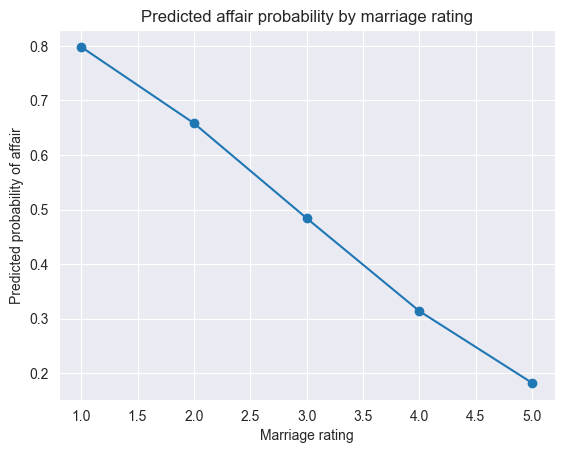

In [66]:
test = pd.DataFrame({
    "rate_marriage": np.arange(1, 6),   # test data for marriages rang of 1-5 and keeps everything else at average
    "age": affairs["age"].mean(),        
    "yrs_married": affairs["yrs_married"].mean(),
    "religious": affairs["religious"].mean(),
    "occupation": affairs["occupation"].mean()
})

X_test = sm.add_constant(test, has_constant="add")   # sets intercept
test["pred_prob"] = best_fit.predict(X_test)
plt.plot(test["rate_marriage"], test["pred_prob"], marker="o")  # shows the variation in predictions as marrige ratings changes
plt.xlabel("Marriage rating")
plt.ylabel("Predicted probability of affair")
plt.title("Predicted affair probability by marriage rating")
plt.show()

In [87]:
print(len(test))
test

5


,rate_marriage,age,yrs_married,religious,occupation,pred_prob
0,1,29.082862,9.009425,2.42617,3.424128,0.797943
1,2,29.082862,9.009425,2.42617,3.424128,0.658128
2,3,29.082862,9.009425,2.42617,3.424128,0.484116
3,4,29.082862,9.009425,2.42617,3.424128,0.313872
4,5,29.082862,9.009425,2.42617,3.424128,0.182336


(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?

### Response 1g
Working with this data set caused me  to think about the people behind the data. Modeling actual affairs could impact families. If this kind of data or prediction ever leaked or was misused, it could lead to divorce battles, custody disputes, or court cases, and could hurt kids, not just the adults in the dataset.

### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [68]:
!pip install ISLP # install islp line 17 wont run wihtout it


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [69]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [70]:
Hitters.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.00000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,322.000000,263.000000
mean,380.928571,101.024845,10.770186,50.909938,48.027950,38.742236,7.444099,2648.68323,717.571429,69.490683,358.795031,330.118012,260.239130,288.937888,106.913043,8.040373,535.925882
std,153.404981,46.454741,8.709037,26.024095,26.166895,21.639327,4.926087,2324.20587,654.472627,86.266061,334.105886,333.219617,267.058085,280.704614,136.854876,6.368359,451.118681
min,16.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,19.00000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.500000
25%,255.250000,64.000000,4.000000,30.250000,28.000000,22.000000,4.000000,816.75000,209.000000,14.000000,100.250000,88.750000,67.250000,109.250000,7.000000,3.000000,190.000000
50%,379.500000,96.000000,8.000000,48.000000,44.000000,35.000000,6.000000,1928.00000,508.000000,37.500000,247.000000,220.500000,170.500000,212.000000,39.500000,6.000000,425.000000
75%,512.000000,137.000000,16.000000,69.000000,64.750000,53.000000,11.000000,3924.25000,1059.250000,90.000000,526.250000,426.250000,339.250000,325.000000,166.000000,11.000000,750.000000
max,687.000000,238.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.00000,4256.000000,548.000000,2165.000000,1659.000000,1566.000000,1378.000000,492.000000,32.000000,2460.000000


In [71]:
Hitters.columns

Index(['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'Years', 'CAtBat',
       'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'League', 'Division',
       'PutOuts', 'Assists', 'Errors', 'Salary', 'NewLeague'],
      dtype='object')

(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

### Response 2a
Do MLB players who draw more Walks tend to earn above average salaries?

(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

### Response 2b
The Hitters dataset includes 322 MLB players with various stats, hits, home runs, runs, rbi, walks, defensive stats, putouts, assists, errors, career totals, and salary. The salary column has 59 missing values that need to be addressed. Most variables are numeric, and League/Division/NewLeague are the only categorical fields. The variables needed to answer the question are Walks and Salary. Some salary values are missing and need to be addressed. Overall, the dataset provides enough detail to determine whether a player’s ability to draw walks is associated with earning above-average pay.

(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

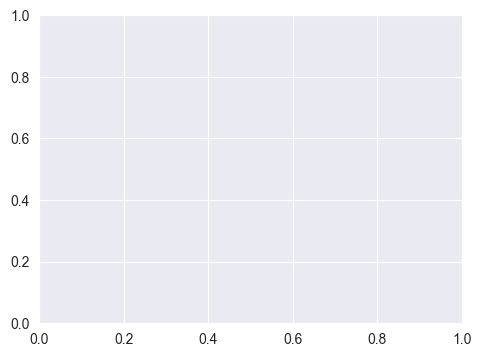

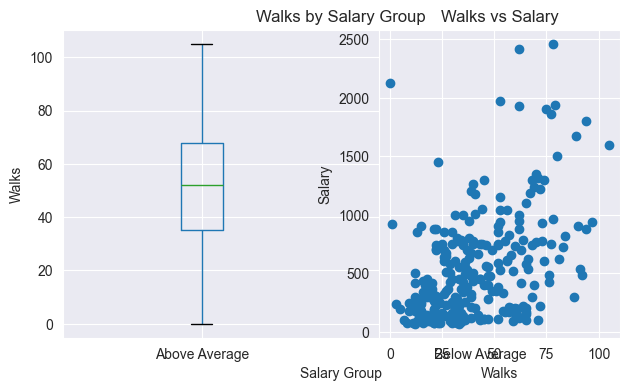

SalaryGroup
Above Average    50.980952
Below Average    34.556962
Name: Walks, dtype: float64

In [72]:
df = Hitters.dropna(subset=["Salary"]).copy() # drop missing salaries

avg_salary = df["Salary"].mean() # average salary

df["SalaryGroup"] = np.where(df["Salary"] > avg_salary,
                             "Above Average", "Below Average")  # create a salary group column
plt.figure(figsize=(12,4)) # two visualizations
plt.subplot(1, 2, 1) # box plot of walks by salary group
df.boxplot(column="Walks", by="SalaryGroup")
plt.title("Walks by Salary Group")
plt.suptitle("")
plt.xlabel("Salary Group")
plt.ylabel("Walks")
plt.subplot(1, 2, 2) # scatterplot walks vs salary
plt.scatter(df["Walks"], df["Salary"])
plt.title("Walks vs Salary")
plt.xlabel("Walks")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()
df.groupby("SalaryGroup")["Walks"].mean() # average
# ive tried multiple things to get rid of this phantom plot, but nothing has worked :(

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?

### Response 2d
My questions were answered pretty easily because the dataset was reasonably clean and had enough numeric variables to compare basic relationships, like walks and salary groups. The simple, descriptive questions worked well.

Complex questions would be more difficult as the dataset is limited to one season and doesn’t include important context (team factors, injuries, contracts, roles). However, the dataset was sufficient to answer my question.

### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In [73]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

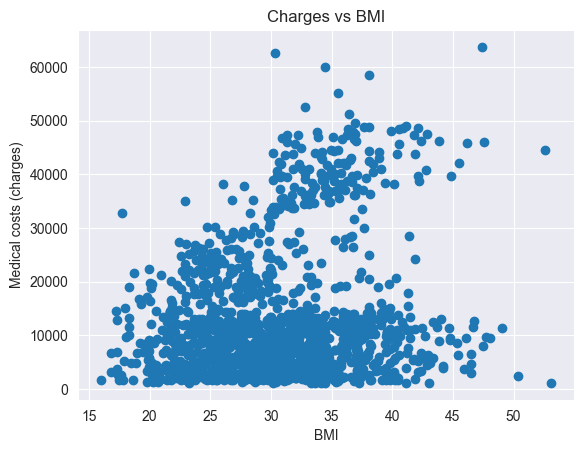

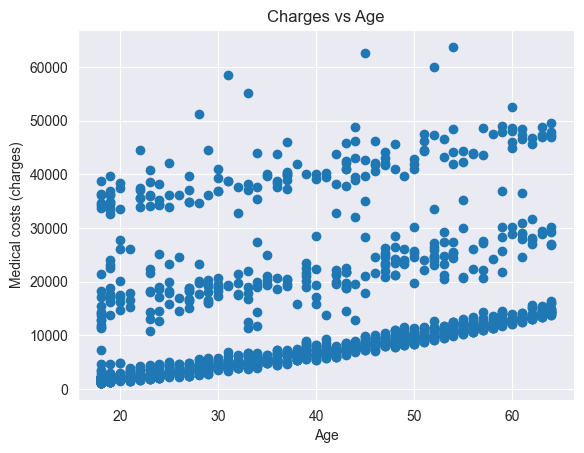

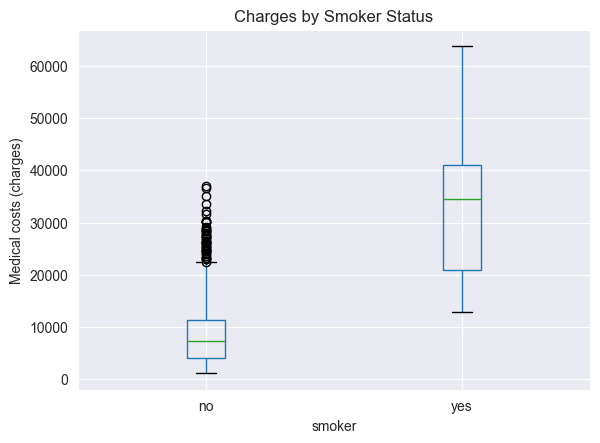

In [74]:
plt.scatter(df["bmi"], df["charges"]) # charges vs bmi
plt.xlabel("BMI")
plt.ylabel("Medical costs (charges)")
plt.title("Charges vs BMI")
plt.show()

plt.scatter(df["age"], df["charges"]) # charges vs age
plt.xlabel("Age")
plt.ylabel("Medical costs (charges)")
plt.title("Charges vs Age")
plt.show()

df.boxplot(column="charges", by="smoker") # boxplot of charges by smoker status
plt.ylabel("Medical costs (charges)")
plt.title("Charges by Smoker Status")
plt.suptitle("")  # gets rid title
plt.show()

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [75]:
X = df[["bmi", "age", "children"]]    # set variables for model & adds intercept
X = sm.add_constant(X)           
y = df["charges"]

model = sm.OLS(y, X).fit() # runs & shows results
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     60.69
Date:                Tue, 02 Dec 2025   Prob (F-statistic):           8.80e-37
Time:                        20:57:15   Log-Likelihood:                -14392.
No. Observations:                1338   AIC:                         2.879e+04
Df Residuals:                    1334   BIC:                         2.881e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6916.2433   1757.480     -3.935      0.000   -1.04e+04   -3468.518
bmi          332.0834     51.310      6.472      0.000     231.425     432.741
age          239.9945     22.289     10.767      0.000     196.269     283.720
children     542.8647    258.241      2.102      0.036      36.261    1049.468
==============================================================================
Omnibus:                      325.395   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              603.372
Skew:                           1.520   Prob(JB):                    9.54e-132
Kurtosis:                       4.255   Cond. No.                         290.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Response 3b
I applied BMI, age, and number of children to fit a multiple linear regression that predicted medical costs.  The coefficient for BMI was positive and statistically significant, indicating that higher BMI is associated with higher charges. It explains a significant amount of the variation, but the model's R² indicates that most of the variation in charges remains due to other factors.

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

### Response 3c
To check the model from part (b), I looked at the differences between the real charges and what the model predicted. The fit is okay, but there are some people with high charges where the model misses by a lot, and larger as charges increase. 

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [76]:
df["sex"] = df["sex"].astype("category").cat.codes # convert columns into number form to uses 
df["smoker"] = df["smoker"].astype("category").cat.codes
df["region"] = df["region"].astype("category").cat.codes

y = df["charges"] # sets variables

available_vars = ["bmi", "age", "children", "sex", "smoker", "region"] # predictors to be tested

selected = []   # empty list for variables

for var in available_vars: # adds variable, rebuilds a small test model, runs model, checks significance, and usefulness
    test_vars = selected + [var]                 
    X_test = sm.add_constant(df[test_vars])           
    model_test = sm.OLS(y, X_test).fit()          
    pval = model_test.pvalues[var]               
    
    if pval < 0.05:                              
        selected.append(var) #keeps if p-vlaue is significant

print("Selected variables:", selected)

X_best = sm.add_constant(df[selected]) # fits best model
best_model = sm.OLS(y, X_best).fit()

best_model.summary() #shows work

Selected variables: ['bmi', 'age', 'children', 'sex', 'smoker', 'region']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.750
Method:                 Least Squares   F-statistic:                     668.1
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        20:57:15   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1331   BIC:                         2.715e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.182e+04    955.130    -12.371      0.000   -1.37e+04   -9941.729
bmi          332.5701     27.722     11.997      0.000     278.186     386.954
age          257.2881     11.886     21.647      0.000     233.971     280.605
children     479.3694    137.644      3.483      0.001     209.346     749.393
sex         -131.1106    332.811     -0.394      0.694    -784.001     521.780
smoker      2.382e+04    411.843     57.839      0.000     2.3e+04    2.46e+04
region      -353.6400    151.927     -2.328      0.020    -651.682     -55.598
==============================================================================
Omnibus:                      299.003   Durbin-Watson:                   2.088
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              713.975
Skew:                           1.207   Prob(JB):                    9.17e-156
Kurtosis:                       5.642   Cond. No.                         296.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Response 3d
My stepwise selection kept the same predictors as the full model: BMI, age, children, sex, smoker, and region. The best model was the full model, and stepwise selection confirmed that all variables were useful for explaining charges.

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [77]:
location = "http://archive.ics.uci.edu/ml/machine-learning-databases/"
dataframe = "breast-cancer-wisconsin/breast-cancer-wisconsin.data"

url = location + dataframe

# Load the dataset directly from the web
df = pd.read_csv(url, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       699 non-null    int64 
 1   1       699 non-null    int64 
 2   2       699 non-null    int64 
 3   3       699 non-null    int64 
 4   4       699 non-null    int64 
 5   5       699 non-null    int64 
 6   6       699 non-null    object
 7   7       699 non-null    int64 
 8   8       699 non-null    int64 
 9   9       699 non-null    int64 
 10  10      699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


### 4a
I pulled the breast cancer dataset from the website per the instructions.  The dataset includes 699 rows and 11 columns Each row describes a patibluar breast tissue sample, each column has a numeric rating (mostly 1–10) describing different cell characteristics.

(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [79]:
df.columns = [ # assign column names
    "sample_code_number",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   sample_code_number      699 non-null    int64 
 1   clump_thickness         699 non-null    int64 
 2   uniformity_cell_size    699 non-null    int64 
 3   uniformity_cell_shape   699 non-null    int64 
 4   marginal_adhesion       699 non-null    int64 
 5   single_epithelial_size  699 non-null    int64 
 6   bare_nuclei             699 non-null    object
 7   bland_chromatin         699 non-null    int64 
 8   normal_nucleoli         699 non-null    int64 
 9   mitoses                 699 non-null    int64 
 10  class                   699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [81]:
df.isna().sum()

sample_code_number        0
clump_thickness           0
uniformity_cell_size      0
uniformity_cell_shape     0
marginal_adhesion         0
single_epithelial_size    0
bare_nuclei               0
bland_chromatin           0
normal_nucleoli           0
mitoses                   0
class                     0
dtype: int64

In [82]:
df.describe()

,sample_code_number,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_size,bland_chromatin,normal_nucleoli,mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [83]:
df['bare_nuclei'].value_counts()

bare_nuclei
1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: count, dtype: int64

### 4b
I assigned column names and used df.info() to analyze the dataset. Most variables are stored as integers, but bare_nuclei was loaded as an object. I checked for missing values with df.isna().sum(), then looked at bare_nuclei and saw 16 missing values coded as ?.

(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [84]:
# normalizing for 4d 
df["bare_nuclei"] = df["bare_nuclei"].replace("?", np.nan) # turns ? into real missing values

df["bare_nuclei"] = pd.to_numeric(df["bare_nuclei"]) # converts column to numbers

df = df.dropna() # drop missing values rows

df["bare_nuclei"].unique()          # should'nt show '?'
df.isin(["?"]).sum()                # check if any column still has '?'

sample_code_number        0
clump_thickness           0
uniformity_cell_size      0
uniformity_cell_shape     0
marginal_adhesion         0
single_epithelial_size    0
bare_nuclei               0
bland_chromatin           0
normal_nucleoli           0
mitoses                   0
class                     0
dtype: int64

In [85]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["class"]) # # uses columns except target as input data and the target we want to predict 
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split( # 70% trainimg and 30% testing
    X, y, test_size=0.30, random_state=42
)

X_train.shape, X_test.shape

((478, 10), (205, 10))

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report # fits ML model and looks at confusion matrix
log_clf = LogisticRegression(max_iter=1000) # uses all features to predict class benign or malignant and trains logistic model with training data
log_clf.fit(X_train, y_train)
y_pred = log_clf.predict(X_test)              # make predictions from test set
cm = confusion_matrix(y_test, y_pred) # confusion matrix and basic stats
print("Confusion matrix:\n", cm)
print(classification_report(y_test, y_pred))

Confusion matrix:
 [[125   2]
 [  6  72]]
              precision    recall  f1-score   support

           2       0.95      0.98      0.97       127
           4       0.97      0.92      0.95        78

    accuracy                           0.96       205
   macro avg       0.96      0.95      0.96       205
weighted avg       0.96      0.96      0.96       205



/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/stevegon/SynologyDrive/code/uw/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: over

#### Resoponse 4d
The confusion matrix showed 125 benign and 71 malignant cases, with only 2 benign cases predicted as malignant false positives and 7 malignant cases predicted as benign false negatives, giving about 96% accuracy. False negatives are the most concerning errors because they can delay diagnosis and treatment by incorrectly labeling malignant tumors as benign. False positives, on the other hand, mostly just lead to more follow-up testing.

### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer.
### Response 5a
I believe classification would be useful at my former employer, a non-profit organization that worked with various populations. For that work I could classify participants as high-risk vs. low-risk using things like overdose history, engagement, and service use. I could also predict whether someone will complete a program complete vs. not complete or automatically label new tickets as urgent, medium, low priority based on issue type and impact. The goal would be to predict a category to guide faster decisions.

b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 

### Response 5b
For regression based on a client's past, income, and support needs, I might be able to guess how long they will stay in temporary housing. I could also use trends in outreach, referrals, and assessment scores to guess how many people will sign up each month or how many hours of service a client will need. The goal here is to guess a number that will help with staffing, budgeting, and planning.

(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?

### Response 5c
Flexible models can identify patterns and deliver improved results. They are ideal when we have abundant high-quality data and when making accurate predictions is the main goal. When clear answers are necessary for leaders or funders, or when data is limited and consistency is key, simpler, less flexible models are a better option.

### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.

### Response 6a
(Answer iii. For a given IQ and GPA, males earn more on average than females, provided the GPA is high enough. 
Using 50 + 20(GPA) + 0.07(IQ) + 35(Gender) + 0.01(GPA×IQ)–10(GPA×Gender) I plugged in the value of the variable we know female = 1 and male = 0 and then calculated and combined like terms. The GPA multiplier is larger for males and smaller for females, but females start with an extra 35 in salary. This indicates females earn more at lower GPAs, and males can earn more once GPA is high enough to overcome the 35 extra in salary for females.
Male Y=50 + 20(GPA) + 0.07(IQ) + 35(0) + 0.01(GPA*IQ) – 10(GPA*0)= 50 + 20(GPA) + 0.07(IQ) + 0.01(GPA*IQ)
Female Y=50 + 20(GPA) + 0.07(IQ) + 35(1) + 0.01(GPA*IQ) – 10(GPA*1) = 85 + 10(GPA) + 0.07IQ + 0.01(GPA*IQ)

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

### Response 6b
After adding the new values for IQ and GPA, it appears that males earn more at 142,100 than their female counterparts at 137,100. 
Male Y=50 + 20(4) + 0.07(110) + 35(0) + 0.01(4*110) – 10(4*0)= 50 + 80 + 7.7 + 0+ 4.4 + 0 = 142.1 
Female Y=50 + 20(4) + 0.07(110) + 35(1) + 0.01(4*110) – 10(4*1) = 50 + 80 + 7.7 + 35 + 4.4 - 40 = 137.1

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

### Response 6c 
False, there is sufficient evidence that there is a significant effect on salary. However, GPA has the greatest impact on the salary gap between males and females.